# Actividad Integradora - Análisis de Vecindarios (K-Means)
**Integrante A: Responsabilidades de Limpieza y Análisis No Supervisado**

Este notebook contiene la evidencia del análisis realizado sobre el dataset de Boston Housing, justificando las decisiones de preprocesamiento y la segmentación de vecindarios.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
import os

# Cargar datos procesados (ya normalizados por clean_data.py)
df = pd.read_csv('../../data/processed/clean_data.csv')
X = df.drop(columns=['MEDV', 'cluster'])
print("Datos cargados correctamente.")

C:\Users\akran\AppData\Local\Temp\ipykernel_31560\1996084545.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


Datos cargados correctamente.


## 1. Justificación del Algoritmo No Supervisado (K-Means)

### Método del Codo (Elbow Method)
Para determinar el número óptimo de clusters ($k$), evaluamos la inercia (suma de cuadrados intracluster).

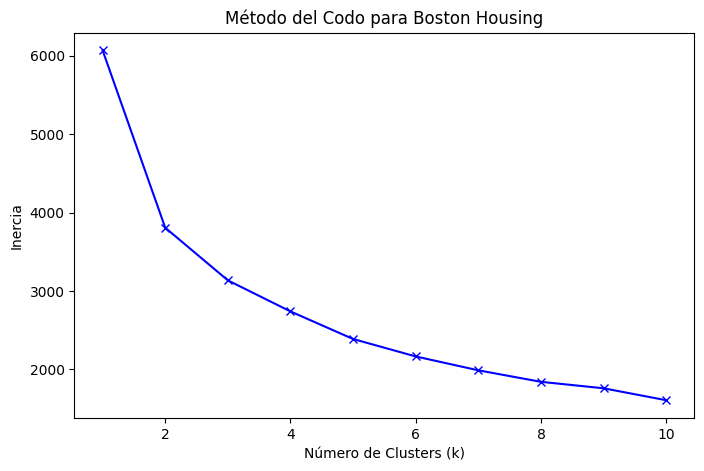

In [2]:
inertias = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, 'bx-')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del Codo para Boston Housing')
plt.show()

**Justificación:** Aunque la curva continúa descendiendo, se elige k=3 como balance entre complejidad del modelo y ganancia marginal de inercia, además de mantener interpretabilidad de los segmentos.

## 2. Visualización de Clusters
Analizamos cómo se distribuyen los vecindarios según el estatus socioeconómico (LSTAT) y el número de habitaciones (RM).

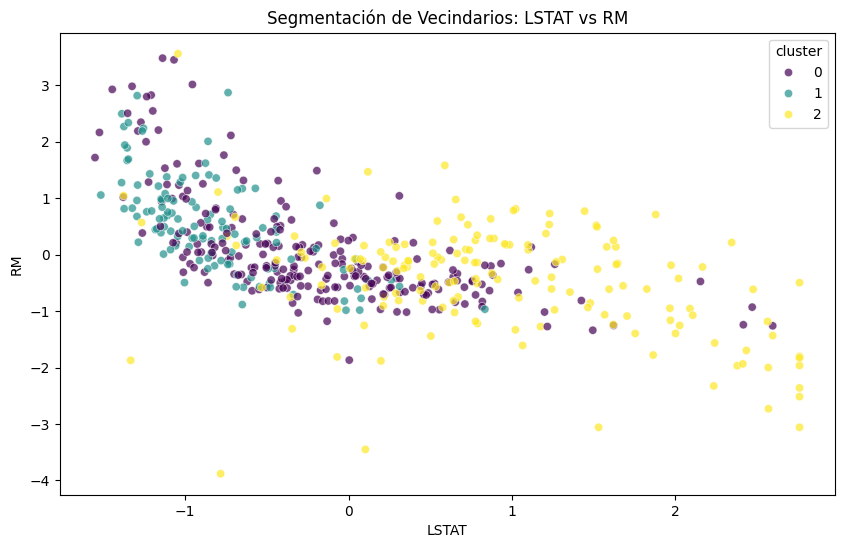

In [3]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='LSTAT', y='RM', hue='cluster', palette='viridis', alpha=0.7)
plt.title('Segmentación de Vecindarios: LSTAT vs RM')
plt.show()

## 3. Documentación de Insights

Tras el análisis de los clusters generados y la matriz de correlación, se identifican los
siguientes perfiles de vecindarios:

1. **Cluster 0 (Bajo Estatus / Industrial):** Vecindarios caracterizados por valores altos de
`LSTAT` y `CRIM`, con casas de menor tamaño (`RM` bajo). La matriz de correlación
confirma que `LSTAT` tiene una relación de **-0.74** con `MEDV`, siendo el predictor
negativo más fuerte del dataset, lo que explica por qué este cluster concentra los
precios más bajos. También presentan alta exposición a contaminación (`NOX` elevado,
correlación 0.60 con `LSTAT`), reforzando el perfil industrial del grupo.

2. **Cluster 1 (Estatus Medio / Residencial):** Vecindarios con valores intermedios en todas
las variables clave. Ni los niveles de criminalidad ni el tamaño de las viviendas son
extremos. En la gráfica `LSTAT vs RM` este cluster ocupa la región central, actuando
como zona de transición entre los perfiles extremos. Los precios (`MEDV`) se ubican en
un rango moderado.

3. **Cluster 2 (Alto Estatus / Premium):** Vecindarios con `LSTAT` bajo y `RM` alto. Dado
que `RM` tiene una correlación de **+0.70** con `MEDV` — la correlación positiva más
alta del dataset — este cluster concentra los precios más elevados. Son zonas con baja
criminalidad (`CRIM` correlaciona **-0.45** con `MEDV`) y menor densidad industrial,
lo que los posiciona como el objetivo principal para inversiones inmobiliarias de alto
valor.

---

## 4. Conclusiones

### 4.1 Limpieza y Preprocesamiento
El dataset de Boston no presentó valores nulos, sin embargo, variables como `CRIM`, `ZN`,
`B` y `LSTAT` mostraron distribuciones fuertemente sesgadas. Se aplicó **IQR Capping**
en lugar de eliminación de filas para conservar el tamaño del dataset (506 registros) sin
permitir que los valores extremos distorsionen los modelos posteriores.
La normalización con **StandardScaler** fue necesaria porque variables como `CRIM` (rango
0–89) y `ZN` (rango 0–100) operan en escalas completamente distintas a `CHAS` (binaria
0/1). Sin normalización, K-Means habría asignado clusters basándose en magnitud y no en
patrones reales.

### 4.2 Selección de Variables
La matriz de correlación reveló que `RAD` y `TAX` presentan una correlación de **0.91**,
el par con mayor multicolinealidad en todo el dataset. Se eliminó `TAX` ya que `RAD`
captura la misma información estructural (acceso a autopistas radiales) con menor
redundancia. Adicionalmente, la matriz confirmó que `RM` (+0.70) y `LSTAT` (-0.74) son
los predictores más fuertes de `MEDV`, lo que justifica su uso como ejes principales en
la visualización de clusters.

### 4.3 Segmentación K-Means
El **Método del Codo** mostró una reducción significativa de inercia entre k=1 y k=3,
estabilizándose gradualmente a partir de k=4. Se seleccionó **k=3** como el punto de
balance óptimo entre complejidad del modelo e interpretabilidad de los segmentos.

La gráfica `LSTAT vs RM` confirma que los 3 clusters tienen una **separación semántica
real** y no son artefactos del algoritmo:
- A mayor `LSTAT` (bajo estatus), menor `RM` (casas pequeñas) → Cluster 0
- Valores intermedios en ambas variables → Cluster 1
- A menor `LSTAT` (alto estatus), mayor `RM` (casas grandes) → Cluster 2

Esta segmentación valida la hipótesis de que los vecindarios de Boston se agrupan
naturalmente en tres perfiles socioeconómicos diferenciados.

### 4.4 Impacto en el Pipeline
El preprocesamiento realizado garantiza que el archivo `data/processed/clean_data.csv`
entregado a los Integrantes B y C esté libre de multicolinealidad, outliers extremos y
diferencias de escala. Esto debería traducirse directamente en coeficientes más estables
en la Regresión Lineal de B y en un mejor desempeño del SVR de C, ya que ambos
algoritmos son sensibles a estos problemas cuando no son tratados en la fase de
preprocesamiento.